#INSTALLING DATA

In [4]:
import os 
from pathlib import Path
import pandas as pd
import requests
data_dir=Path(os.getcwd())
url="https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns=columns = [
        "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
        "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
    ]
try:
    response=requests.get(url,timeout=40)
    response.raise_for_status()
    raw_file="dataset.data"
    with open(raw_file,"w") as f:
        f.write(response.text)
    df=pd.read_csv(
        raw_file,
        names=columns,
        na_values="?",
        sep=","
    )
    df["target"] = (df["target"] > 0).astype(int)
    output_file = data_dir / "heart_disease.csv"
    df.to_csv(output_file, index=False)
except Exception as e:
    print(f"error:{e}")
    raise




In [6]:
print(df.head)

<bound method NDFrame.head of       age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0    63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1    67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2    67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3    37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4    41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   
..    ...  ...  ...       ...    ...  ...      ...      ...    ...      ...   
298  45.0  1.0  1.0     110.0  264.0  0.0      0.0    132.0    0.0      1.2   
299  68.0  1.0  4.0     144.0  193.0  1.0      0.0    141.0    0.0      3.4   
300  57.0  1.0  4.0     130.0  131.0  0.0      0.0    115.0    1.0      1.2   
301  57.0  0.0  2.0     130.0  236.0  0.0      2.0    174.0    0.0      0.0   
302  38.0  1.0  3.0     138.0  175.0  0.0      0.0    173.0    0.0      0.0   

     slope   ca  thal

STARTING VISUALIZATIONS

In [7]:
import matplotlib.pyplot as plt

In [8]:
missing_values=df.isnull().sum()
print(missing_values[missing_values>0])

ca      4
thal    2
dtype: int64


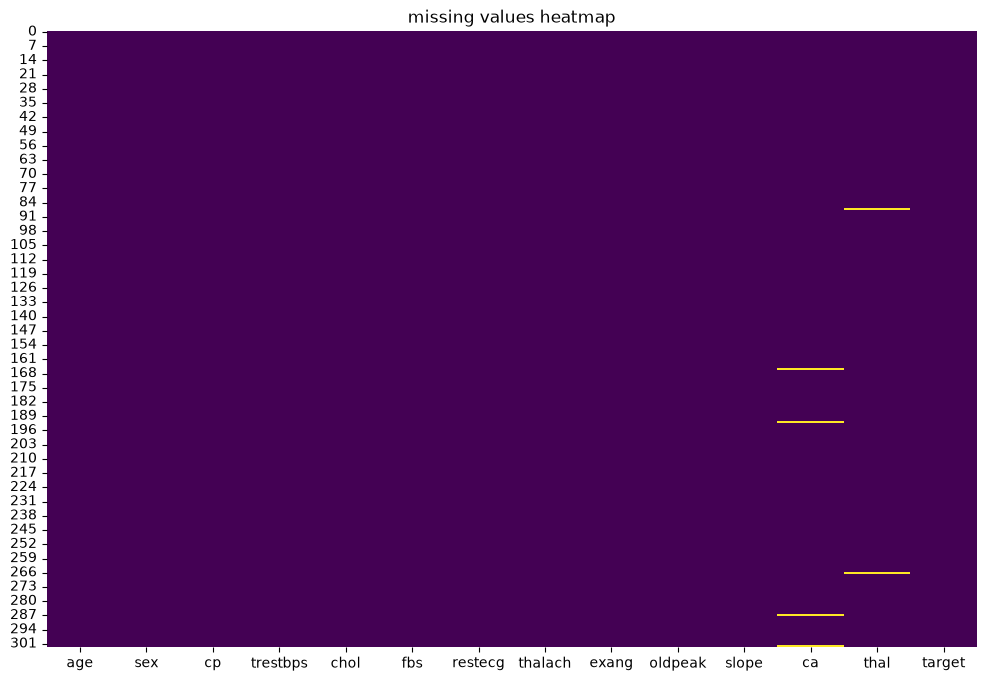

In [9]:
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(df.isnull() ,cbar=False ,cmap="viridis")
plt.title('missing values heatmap')
plt.show()

CORRELATIONS ANALYSIS

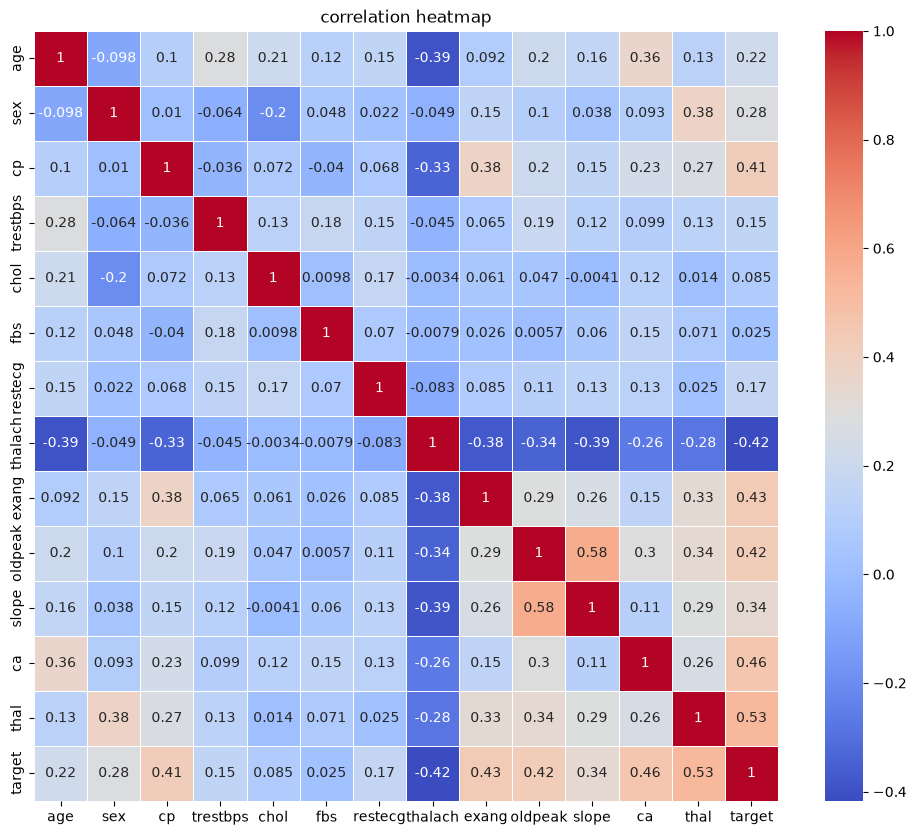

In [11]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm",linewidths=0.5)
plt.title("correlation heatmap")
plt.show()

HANDLING MISSING VALUES


In [18]:
from sklearn.impute import SimpleImputer
imputer= SimpleImputer(strategy='median')
imputer.fit(df)
df[df.columns] = imputer.fit_transform(df)

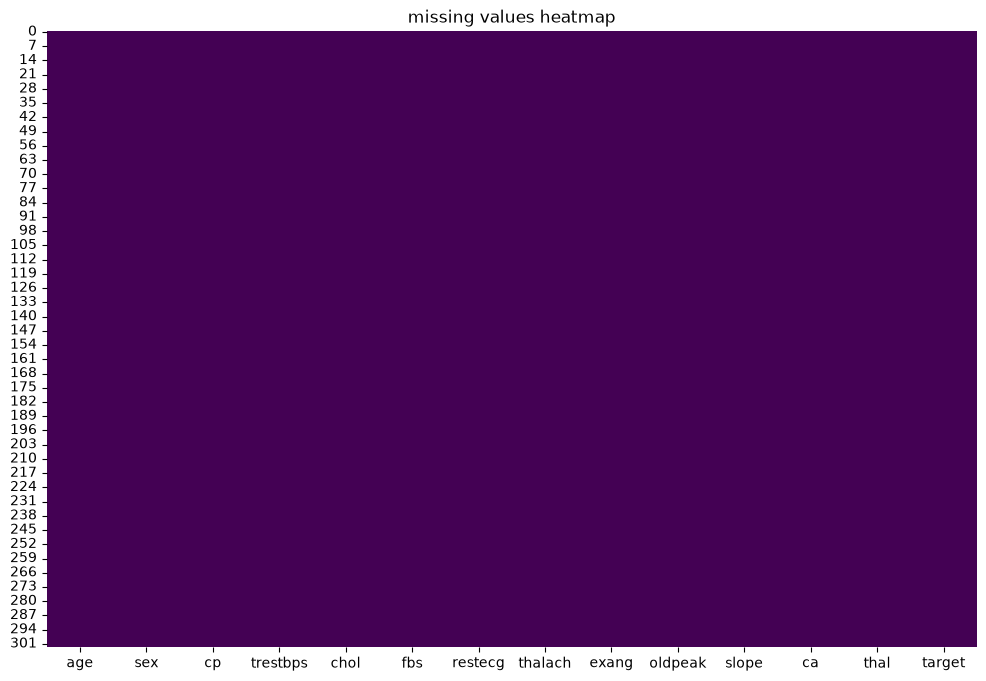

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(df.isnull() ,cbar=False ,cmap="viridis")
plt.title('missing values heatmap')
plt.show()